### [ QQ Plot - 정규성/왜도/첨도 체크 ]
- 정규분포 가정이 필요한 모델이서 필수 :
    - 선형회귀(OLS) : 잔차가 정규인지 확인
    - ANOVA, t-test : 데이터 정규성
    - Box-Cox 변화 필요 여부 판단
    - 치우침 개선 전/후 비교
    - 이상치(outlier) 탐지
    
- 무슨 변환을 해야하는 방향성도 잡아줌

In [29]:
## =====================================
## 모듈 로딩
## =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from scipy.stats import skew, kurtosis
from scipy.stats import probplot        ## qqplot 그려주는 함수
from scipy.stats import boxcox, yeojohnson


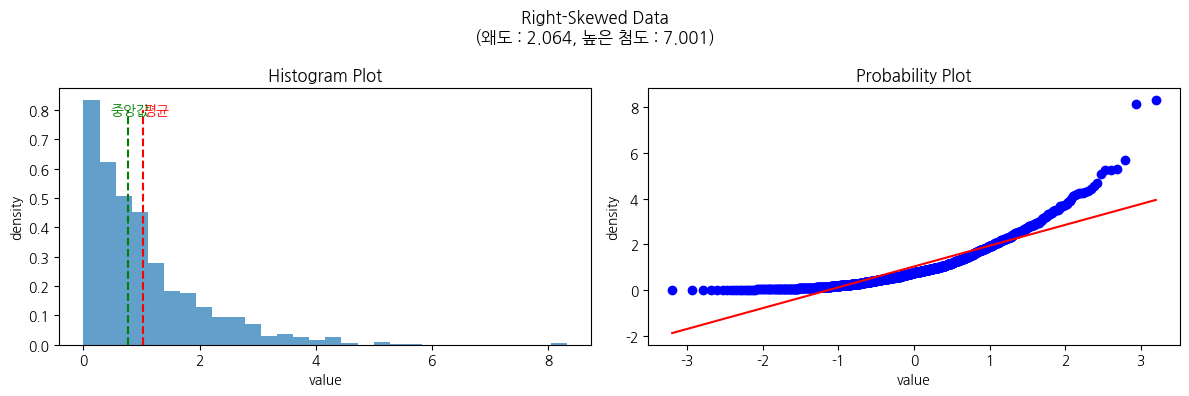

In [34]:
## 임시데이터 - 왼쪽 솔린 데이터
x = np.random.exponential(size=1000)
x_mean = np.mean(x)
x_median = np.median(x)
x_skew = skew(x, bias=False)
x_ku = kurtosis(x, fisher=True, bias=False)
## ====================================================
## 데이터 분포 시각화 - 히스토그램
## ====================================================
fig, axes = plt.subplots(1,2,figsize = (12,4))

## 정규분포 데이터 히스토그램
axes[0].hist(x, bins=30, density=True, alpha=0.7)
axes[0].vlines(x_mean, 0, 0.8, color='red', linestyles='dashed')
axes[0].vlines(x_median, 0, 0.8, color='green', linestyles='dashed')

axes[0].text(x_mean, axes[0].get_ylim()[1]*0.9, '평균', color='red')
axes[0].text(x_median-0.3, axes[0].get_ylim()[1]*0.9, '중앙값', color='green')

axes[0].set_title('Histogram Plot')
axes[0].set_xlabel('value')
axes[0].set_ylabel('density')

## 치우친 데이터 히스토그램
probplot(x, dist='norm', plot=axes[1])
axes[1].set_xlabel('value')
axes[1].set_ylabel('density')


plt.suptitle(f'Right-Skewed Data\n(왜도 : {x_skew:.3f}, 높은 첨도 : {x_ku:.3f})')
plt.tight_layout()
plt.show()


In [ ]:
## ==========================================================
## 데이터의 기술 통계량 보기
## ==========================================================

def print_stats(series, name) :
    ## ndarray 타입
    x = series
    
    ##  평균, 표준편차(ddof=1 불편분산, 표본 데이터이기 때문)
    mean = x.mean()
    std = x.std()
    
    ## 왜도 (skewness) : 비대칭 정도
    sk = skew(x,bias = False)
    
    ## 첨도 : 뾰족 정도 => 이상치 체크
    ku = kurtosis(x,fisher=True, bias=False)
    
    print(f' ==== {name} 데이터 통계 ====')
    print(f'개   수 : {len(x)}')
    print(f'평   균 : {mean}')
    print(f'표준편차 : {std}')
    print(f'왜   도 : {sk}')
    print(f'첨   도 : {ku}')
    print()



 ==== 원본 양수 데이터(Exponential) 데이터 통계 ====
개   수 : 1000
평   균 : 0.9725059479652244
표준편차 : 0.972023509593197
왜   도 : 1.8678371468010975
첨   도 : 5.250034985091412

 ==== Box-Cox 변환 데이터 (lambda= 0.246) 데이터 통계 ====
개   수 : 1000
평   균 : -0.4105905884543011
표준편차 : 1.0216665817951982
왜   도 : -0.055334594880689494
첨   도 : -0.46798285882959734

 ==== 원본 실수 데이터 (Laplace) 데이터 통계 ====
개   수 : 1000
평   균 : 0.03910747357573097
표준편차 : 1.4317285990882256
왜   도 : 0.2971658841390683
첨   도 : 2.0158955686204045

 ==== Yeo-Johnson 변환 데이터 (lambda=0.934) 데이터 통계 ====
개   수 : 1000
평   균 : -0.0014432740879835749
표준편차 : 1.4259292285519631
왜   도 : 0.02623641255318728
첨   도 : 1.8205232688339157



In [43]:
## ======================================================================
## Box-Cox 예제 (양수 데이터) : 오른쪽 꼬리가 긴 지수분포 데이터를 사용
## ======================================================================
np.random.seed(42)
x_pos = np.random.exponential(scale=1.0, size=1000) # > 0
print_stats(x_pos, '원본 양수 데이터(Exponential)')

## Box-Cox 변환 (양수만 가능)
x_boxcox, lambda_bc = boxcox(x_pos) # lamda 자동추천
print_stats(x_boxcox, f'Box-Cox 변환 데이터 (lambda={lambda_bc : .3f})')

## ==============================================================================
## Yeo-Johnson 예제 (음수 포함 데이터) : 평균 0, 양/음 혼합된 치우친 분포 데이터 사용
## ==============================================================================
## 평균 0, 표준편차 1
x_any = np.random.laplace(loc=0.0, scale=1.0, size=1000) # 음수/양수 혼합

print_stats(x_any, '원본 실수 데이터 (Laplace)')

## Yeo-Johnson 변환 (음수 포함 가능)
x_yj, lambda_yj = yeojohnson(x_any)
print_stats(x_yj, f'Yeo-Johnson 변환 데이터 (lambda={lambda_yj:.3f})')


 ==== 원본 양수 데이터(Exponential) 데이터 통계 ====
개   수 : 1000
평   균 : 0.9725059479652244
표준편차 : 0.972023509593197
왜   도 : 1.8678371468010975
첨   도 : 5.250034985091412

 ==== Box-Cox 변환 데이터 (lambda= 0.246) 데이터 통계 ====
개   수 : 1000
평   균 : -0.4105905884543011
표준편차 : 1.0216665817951982
왜   도 : -0.055334594880689494
첨   도 : -0.46798285882959734

 ==== 원본 실수 데이터 (Laplace) 데이터 통계 ====
개   수 : 1000
평   균 : 0.03910747357573097
표준편차 : 1.4317285990882256
왜   도 : 0.2971658841390683
첨   도 : 2.0158955686204045

 ==== Yeo-Johnson 변환 데이터 (lambda=0.934) 데이터 통계 ====
개   수 : 1000
평   균 : -0.0014432740879835749
표준편차 : 1.4259292285519631
왜   도 : 0.02623641255318728
첨   도 : 1.8205232688339157



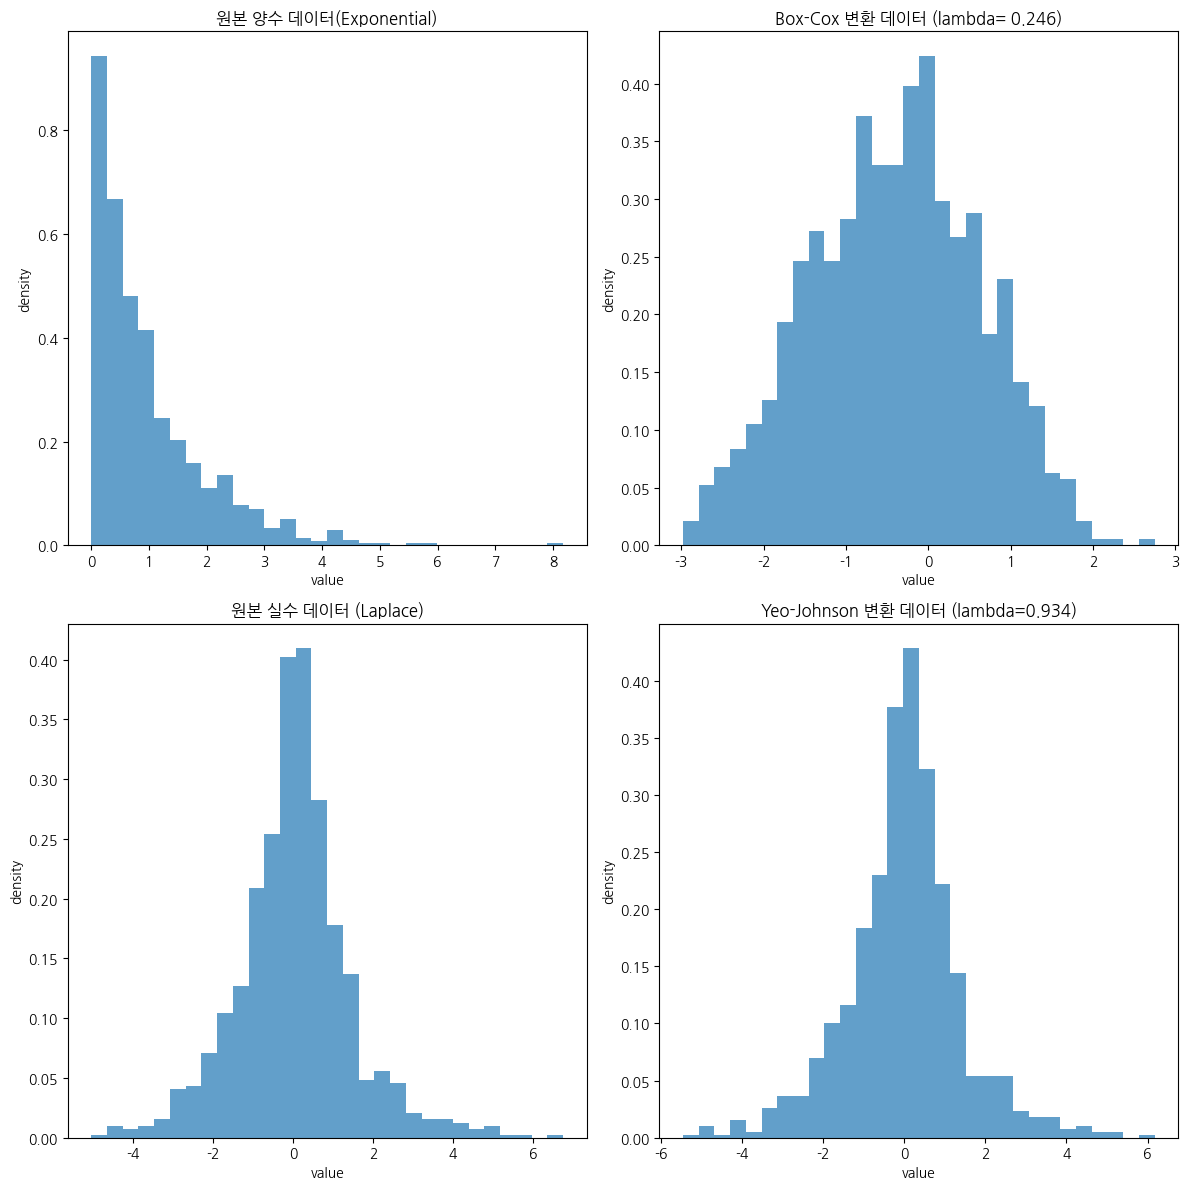

In [45]:
## =======================================================
## 시각화 : 히스토그램 + QQ Plot
## =======================================================
## QQ Plot(Quantile-Quantile Plot)
## => 데이터가 특정 분포(보통 정규분포)를 따르는지 시각적으로
## => 판단하기 위한 그래프
## ======================================================
fig, axes = plt.subplots(2,2,figsize=(12,12))


    ## 히스토그램
ax_hist = axes[0,0]
ax_hist.hist(x_pos,bins=30, density=True, alpha=0.7)
ax_hist.set_title(f'원본 양수 데이터(Exponential)')
ax_hist.set_xlabel('value')
ax_hist.set_ylabel('density')

ax_hist = axes[0,1]
ax_hist.hist(x_boxcox,bins=30, density=True, alpha=0.7)
ax_hist.set_title(f'Box-Cox 변환 데이터 (lambda={lambda_bc : .3f})')
ax_hist.set_xlabel('value')
ax_hist.set_ylabel('density')

ax_hist = axes[1,0]
ax_hist.hist(x_any,bins=30, density=True, alpha=0.7)
ax_hist.set_title(f'원본 실수 데이터 (Laplace)')
ax_hist.set_xlabel('value')
ax_hist.set_ylabel('density')

ax_hist = axes[1,1]
ax_hist.hist(x_yj,bins=30, density=True, alpha=0.7)
ax_hist.set_title(f'Yeo-Johnson 변환 데이터 (lambda={lambda_yj:.3f})')
ax_hist.set_xlabel('value')
ax_hist.set_ylabel('density')

plt.tight_layout()
plt.show()    